In [1]:
# ============================================================
# Cross-lingual Syntactic Patching (Phase 4)
# 实验目标：将 EN clean 句在 syntactic role 对齐位置的激活
#           注入 DE corrupted 句的对应位置
#           观察 DE 的 agreement logit 是否恢复
#
# 三组对照：
#   ✅ Positive Control : EN clean  → DE corr（预期 logit 提升）
#   ❌ Negative Control : EN corr   → DE corr（预期无提升或下降）
#   🔲 Position Control : EN clean 激活注入 DE 无关位置（预期无影响）
#
# 统一化修复点（与单语言版本对齐）：
#   1. 解析函数统一为 resolve_token_indices(item, tokenizer, lang)
#   2. metadata 字段明确使用对应语言的 {lang}_meta，避免 EN/DE 混用
#   3. get_activations hook 统一在 attention.self
#   4. 补充 cross-lingual circuit ablation 验证（单语言已有）
#   5. 不过滤 delta，使用全部 index 解析成功的样本
# ============================================================

# =============================================
# Cell 1: 环境配置与模型加载
# =============================================

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import sys
import itertools
from collections import defaultdict

sys.path.append("/mnt/ssd/weicheng/data_interns/yahan/syntactic-parsing/src/")
from train_parser import BiaffineDependencyParser, mask_arc_scores
from transformers import AutoModel, AutoTokenizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint_path = "/mnt/ssd/weicheng/data_interns/yahan/syntactic-parsing/models/last4_de/best_model.pt"
print(f"正在从 {checkpoint_path} 加载模型...")
checkpoint = torch.load(checkpoint_path, map_location=device)
args = checkpoint["args"]

tokenizer  = AutoTokenizer.from_pretrained(args["model_name"])
encoder    = AutoModel.from_pretrained(args["model_name"])
num_labels = checkpoint["model_state_dict"]["rel_biaffine.weight"].shape[0]

model = BiaffineDependencyParser(
    encoder=encoder,
    num_labels=num_labels,
    hidden_size=encoder.config.hidden_size,
    mlp_size=args["mlp_size"],
    dropout=args["dropout"],
)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device).eval()

n_layers = model.encoder.config.num_hidden_layers
n_heads  = model.encoder.config.num_attention_heads
head_dim = model.encoder.config.hidden_size // n_heads
print(f"模型加载成功！设备: {device} | layers={n_layers}, heads={n_heads}, head_dim={head_dim}")

/mnt/ssd/weicheng/data_interns/yahan/anaconda3/envs/xlmr_parse/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


正在从 /mnt/ssd/weicheng/data_interns/yahan/syntactic-parsing/models/last4_de/best_model.pt 加载模型...
模型加载成功！设备: cuda | layers=12, heads=12, head_dim=64


In [2]:
# =============================================
# Cell 1b: 加载 EN 模型
# =============================================

EN_CHECKPOINT_PATH = "/mnt/ssd/weicheng/data_interns/yahan/syntactic-parsing/models/last4_en/best_model.pt"
print(f"正在从 {EN_CHECKPOINT_PATH} 加载 EN 模型...")
en_checkpoint = torch.load(EN_CHECKPOINT_PATH, map_location=device)
en_args = en_checkpoint["args"]

en_encoder    = AutoModel.from_pretrained(en_args["model_name"])
en_num_labels = en_checkpoint["model_state_dict"]["rel_biaffine.weight"].shape[0]

model_en = BiaffineDependencyParser(
    encoder=en_encoder,
    num_labels=en_num_labels,
    hidden_size=en_encoder.config.hidden_size,
    mlp_size=en_args["mlp_size"],
    dropout=en_args["dropout"],
)
model_en.load_state_dict(en_checkpoint["model_state_dict"])
model_en.to(device).eval()

# XLM-R 共享 tokenizer，直接复用
print(f"EN 模型加载成功！")
print(f"  DE model: {args['model_name']}")
print(f"  EN model: {en_args['model_name']}")


正在从 /mnt/ssd/weicheng/data_interns/yahan/syntactic-parsing/models/last4_en/best_model.pt 加载 EN 模型...


KeyboardInterrupt: 

In [ ]:
# =============================================
# Cell 2: 工具函数（与单语言完全统一）
# =============================================

def get_first_subword_token(tokenizer, text, word_idx):
    """word_idx: 0-based index in text.split()"""
    words = text.split()
    enc = tokenizer(words, is_split_into_words=True, add_special_tokens=True)
    word_ids = enc.word_ids()
    for i, wid in enumerate(word_ids):
        if wid == word_idx and (i == 0 or word_ids[i-1] != word_idx):
            return i
    return None


def find_word_idx(text, word_form):
    """大小写不敏感，先精确匹配，再前缀匹配"""
    if not word_form:
        return None
    words = text.split()
    for i, w in enumerate(words):
        if w.lower() == word_form.lower():
            return i
    for i, w in enumerate(words):
        if w.lower().startswith(word_form.lower()):
            return i
    return None


def resolve_token_indices(item, tokenizer, lang):
    """
    统一的 token index 解析函数，与单语言版本完全一致。
    ★ 修复：明确使用 {lang}_meta，避免 EN metadata 被用于解析 DE 句子。

    参数：
        item     : 数据条目，包含 {lang}_clean / {lang}_corr /
                   {lang}_indices / {lang}_meta 字段
        tokenizer: 分词器
        lang     : "en" 或 "de"
    返回：
        dict，包含 subj/verb 的 clean/corr token index 及 word index
    """
    clean_text = item[f"{lang}_clean"]
    corr_text  = item[f"{lang}_corr"]
    indices    = item.get(f"{lang}_indices", {})

    # ★ 关键修复：优先使用对应语言的 metadata
    meta = item.get(f"{lang}_meta", item.get("metadata", {}))

    # ── subj word index ──
    subj_word_idx = indices.get("subj")
    words = clean_text.split()
    subj_form = meta.get("subj_form", "")
    if subj_word_idx is not None:
        if subj_word_idx >= len(words) or \
           words[subj_word_idx].lower() != subj_form.lower():
            subj_word_idx = find_word_idx(clean_text, subj_form)
    else:
        subj_word_idx = find_word_idx(clean_text, subj_form)

    # ── verb word index ──
    verb_form = meta.get("verb_form", "")
    verb_word_idx = find_word_idx(clean_text, verb_form)
    if verb_word_idx is None:
        verb_word_idx = indices.get("verb")

    # ── subword token indices ──
    subj_tok_clean = get_first_subword_token(tokenizer, clean_text, subj_word_idx) \
                     if subj_word_idx is not None else None
    verb_tok_clean = get_first_subword_token(tokenizer, clean_text, verb_word_idx) \
                     if verb_word_idx is not None else None
    subj_tok_corr  = get_first_subword_token(tokenizer, corr_text, subj_word_idx) \
                     if subj_word_idx is not None else None
    verb_tok_corr  = get_first_subword_token(tokenizer, corr_text, verb_word_idx) \
                     if verb_word_idx is not None else None

    return {
        "subj_tok_clean": subj_tok_clean,
        "verb_tok_clean": verb_tok_clean,
        "subj_tok_corr":  subj_tok_corr,
        "verb_tok_corr":  verb_tok_corr,
        "subj_word_idx":  subj_word_idx,
        "verb_word_idx":  verb_word_idx,
    }


def apply_first_subword_mask(arc_scores, tokenizer, text, device):
    words = text.split()
    enc = tokenizer(words, is_split_into_words=True, add_special_tokens=True)
    word_ids = enc.word_ids()
    mask = torch.tensor([[
        1 if (word_ids[i] is not None and
              (i == 0 or word_ids[i] != word_ids[i-1])) else 0
        for i in range(len(word_ids))
    ]]).to(device)
    return mask_arc_scores(arc_scores, mask)


def get_arc_logit(arc_scores, subj_tok, verb_tok):
    """取 arc_scores[0, subj_tok, verb_tok]，任一为 None 则返回 None"""
    if subj_tok is None or verb_tok is None:
        return None
    return arc_scores[0, subj_tok, verb_tok].item()


def get_agreement_delta(model, tokenizer, item, lang, device):
    """
    agreement_delta = logit(subj→correct_verb | clean句)
                    - logit(subj→incorrect_verb | corr句)
    delta > 0 表示模型对正确形态更有信心。
    与单语言版本完全一致，通过 lang 参数区分语言。
    """
    tok = item[f"_tok_{lang}"]
    if tok["subj_tok_clean"] is None or tok["verb_tok_clean"] is None:
        return None, None, None

    # clean
    clean_inp = tokenizer(item[f"{lang}_clean"], return_tensors="pt").to(device)
    with torch.no_grad():
        out = model(**clean_inp)
        arc = out[0] if isinstance(out, (tuple, list)) else out.arc_scores
    arc = apply_first_subword_mask(arc, tokenizer, item[f"{lang}_clean"], device)
    clean_logit = get_arc_logit(arc, tok["subj_tok_clean"], tok["verb_tok_clean"])

    # corr
    corr_inp = tokenizer(item[f"{lang}_corr"], return_tensors="pt").to(device)
    with torch.no_grad():
        out = model(**corr_inp)
        arc = out[0] if isinstance(out, (tuple, list)) else out.arc_scores
    arc = apply_first_subword_mask(arc, tokenizer, item[f"{lang}_corr"], device)
    corr_logit = get_arc_logit(arc, tok["subj_tok_corr"], tok["verb_tok_corr"])

    if clean_logit is None or corr_logit is None:
        return None, None, None

    return clean_logit, corr_logit, clean_logit - corr_logit


def get_activations(model, inputs):
    """
    ★ 统一在 attention.self 输出缓存激活（pre-projection）
    与单语言版本和 patching hook 位置保持一致
    """
    activations = {}
    def save_hook(name):
        def hook(mod, inp, out):
            val = out[0] if isinstance(out, tuple) else out
            activations[name] = val.detach()
        return hook
    handles = [
        layer.attention.self.register_forward_hook(save_hook(f"layer_{i}"))
        for i, layer in enumerate(model.encoder.encoder.layer)
    ]
    with torch.no_grad():
        _ = model(**inputs)
    for h in handles:
        h.remove()
    return activations


print("✅ 工具函数定义完成")

✅ 工具函数定义完成


In [ ]:
# =============================================
# Cell 3: 数据加载与配对
# ★ 修复：去掉歧义的 "metadata" 字段
#         各语言 metadata 分别存为 en_meta / de_meta
# =============================================

EN_JSONL_PATH = "../data/en_100_cleaned_data.jsonl"
DE_JSONL_PATH = "../data/de_100_cleaned_data.jsonl"


def load_jsonl(path):
    data = {}
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            item = json.loads(line.strip())
            data[item["id"]] = item
    return data


en_data = load_jsonl(EN_JSONL_PATH)
de_data = load_jsonl(DE_JSONL_PATH)

common_ids = sorted(set(en_data.keys()) & set(de_data.keys()))
paired_dataset = []
for id_ in common_ids:
    item = {
        "id":         id_,
        # EN 字段
        "en_clean":   en_data[id_]["en_clean"],
        "en_corr":    en_data[id_]["en_corr"],
        "en_indices": en_data[id_]["en_indices"],
        "en_meta":    en_data[id_].get("metadata", {}),   # ★ EN metadata
        # DE 字段
        "de_clean":   de_data[id_]["de_clean"],
        "de_corr":    de_data[id_]["de_corr"],
        "de_indices": de_data[id_]["de_indices"],
        "de_meta":    de_data[id_].get("metadata", {}),   # ★ DE metadata
        # ★ 不再设置歧义的 "metadata" 字段
    }
    paired_dataset.append(item)

print(f"EN: {len(en_data)} 条 | DE: {len(de_data)} 条 | 配对成功: {len(paired_dataset)} 条")

# ── Token index 解析（EN 和 DE 各自用对应语言的 meta）──
errors = []
for item in paired_dataset:
    item["_tok_en"] = resolve_token_indices(item, tokenizer, "en")
    item["_tok_de"] = resolve_token_indices(item, tokenizer, "de")
    for lang in ["en", "de"]:
        tok = item[f"_tok_{lang}"]
        if any(v is None for v in tok.values()):
            errors.append(f"id={item['id']} lang={lang} | {tok}")

print(f"✅ Token index 解析完成，{len(errors)} 条有问题")
for e in errors[:5]:
    print(" ", e)

# ── 抽样校验 ──
for item in paired_dataset[:2]:
    for lang in ["en", "de"]:
        tok = item[f"_tok_{lang}"]
        cw  = item[f"{lang}_clean"].split()
        rw  = item[f"{lang}_corr"].split()
        sw, vw = tok["subj_word_idx"], tok["verb_word_idx"]
        print(f"id={item['id']} [{lang.upper()}]  "
              f"subj='{cw[sw] if sw is not None else None}'  "
              f"verb_clean='{cw[vw] if vw is not None else None}' "
              f"verb_corr='{rw[vw] if vw is not None else None}'")

EN: 70 条 | DE: 70 条 | 配对成功: 70 条
✅ Token index 解析完成，0 条有问题
id=1 [EN]  subj='body'  verb_clean='equals' verb_corr='equal'
id=1 [DE]  subj='Schülerschaft'  verb_clean='bedeutet' verb_corr='bedeuten'
id=3 [EN]  subj='Panels'  verb_clean='Look' verb_corr='Looks'
id=3 [DE]  subj='Paneele'  verb_clean='sehen' verb_corr='sieht'


📊 计算 baseline agreement delta（DE 模型）...
总配对: 70 | DE delta 可计算: 70

--- DE Baseline (DE 模型) ---
  Mean clean logit : -1.3399
  Mean corr  logit : -1.6724
  Mean delta       : 0.3325
  delta > 0 比例   : 61.43%

--- EN Baseline (DE 模型跑 EN 句，仅供参考) ---
  Mean delta : -0.4317  (方向可能为负，正常)


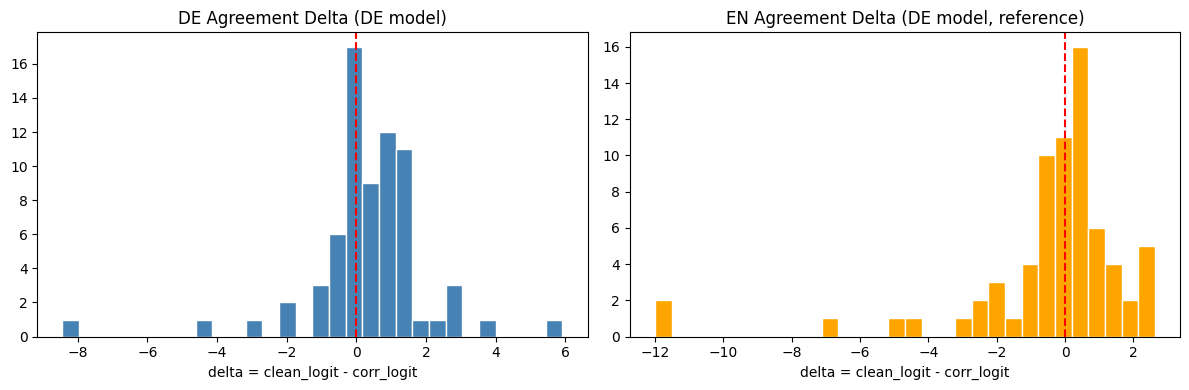


使用全部有效样本: 70 条


In [ ]:
# =============================================
# Cell 4: Baseline Agreement Delta（DE 模型）
# 不过滤 delta，使用全部 index 解析成功的样本
# =============================================

print("📊 计算 baseline agreement delta（DE 模型）...")

results_baseline = []
for item in paired_dataset:
    en_cl, en_co, en_d = get_agreement_delta(model, tokenizer, item, "en", device)
    de_cl, de_co, de_d = get_agreement_delta(model, tokenizer, item, "de", device)
    results_baseline.append({
        "item":           item,
        "en_clean_logit": en_cl, "en_corr_logit": en_co, "en_delta": en_d,
        "de_clean_logit": de_cl, "de_corr_logit": de_co, "de_delta": de_d,
    })

# 使用全部 DE delta 可计算的样本，不过滤方向
valid = [r for r in results_baseline if r["de_delta"] is not None]
print(f"总配对: {len(paired_dataset)} | DE delta 可计算: {len(valid)}")

print(f"\n--- DE Baseline (DE 模型) ---")
print(f"  Mean clean logit : {np.mean([r['de_clean_logit'] for r in valid]):.4f}")
print(f"  Mean corr  logit : {np.mean([r['de_corr_logit']  for r in valid]):.4f}")
print(f"  Mean delta       : {np.mean([r['de_delta'] for r in valid]):.4f}")
print(f"  delta > 0 比例   : {np.mean([r['de_delta'] > 0 for r in valid]):.2%}")

en_valid = [r for r in results_baseline if r["en_delta"] is not None]
print(f"\n--- EN Baseline (DE 模型跑 EN 句，仅供参考) ---")
print(f"  Mean delta : {np.mean([r['en_delta'] for r in en_valid]):.4f}"
      f"  (方向可能为负，正常)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist([r["de_delta"] for r in valid], bins=30,
             color="steelblue", edgecolor="white")
axes[0].axvline(0, color="red", linestyle="--")
axes[0].set_title("DE Agreement Delta (DE model)")
axes[0].set_xlabel("delta = clean_logit - corr_logit")
axes[1].hist([r["en_delta"] for r in en_valid], bins=30,
             color="orange", edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("EN Agreement Delta (DE model, reference)")
axes[1].set_xlabel("delta = clean_logit - corr_logit")
plt.tight_layout()
plt.savefig("baseline_delta_distribution.png", dpi=150)
plt.show()

# 使用全部有效样本
filtered        = valid
filtered_dataset = [r["item"] for r in filtered]
print(f"\n使用全部有效样本: {len(filtered_dataset)} 条")

📊 计算 EN 模型 baseline agreement delta（EN 句）...
总配对: 70 | EN delta 可计算: 70
  Mean clean logit : -2.6359
  Mean corr  logit : -3.1090
  Mean delta       : 0.4730
  delta > 0 比例   : 67.14%


/tmp/ipykernel_494793/1603110633.py:38: UserWarning: Glyph 21442 (\N{CJK UNIFIED IDEOGRAPH-53C2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_494793/1603110633.py:38: UserWarning: Glyph 29031 (\N{CJK UNIFIED IDEOGRAPH-7167}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_494793/1603110633.py:39: UserWarning: Glyph 21442 (\N{CJK UNIFIED IDEOGRAPH-53C2}) missing from font(s) DejaVu Sans.
  plt.savefig("baseline_en_model_delta.png", dpi=150)
/tmp/ipykernel_494793/1603110633.py:39: UserWarning: Glyph 29031 (\N{CJK UNIFIED IDEOGRAPH-7167}) missing from font(s) DejaVu Sans.
  plt.savefig("baseline_en_model_delta.png", dpi=150)


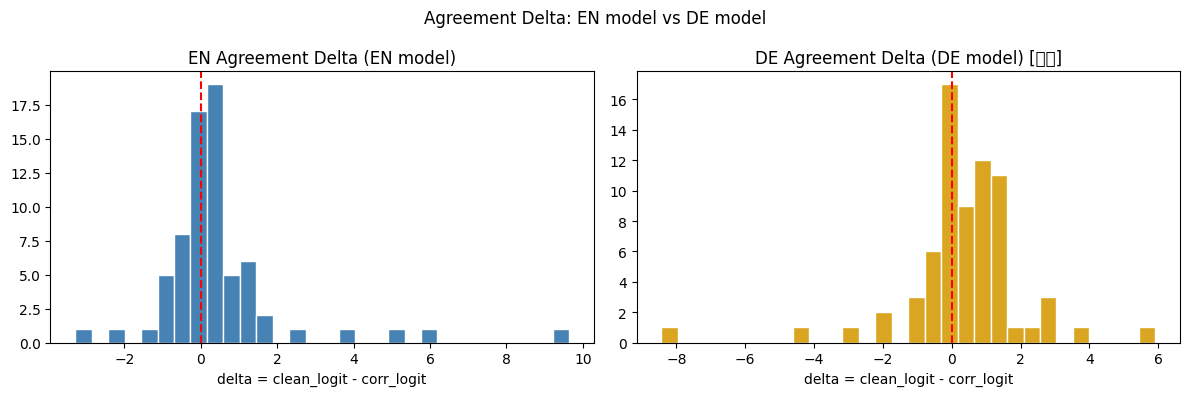


EN 模型有效样本（用于后续 EN ablation）: 70 条


In [ ]:
# =============================================
# Cell 3b: EN 模型 Baseline（EN 句）
# 用 EN 模型建立 EN agreement delta baseline，
# 归一化后续 EN 侧 ablation drop。
# =============================================

print("📊 计算 EN 模型 baseline agreement delta（EN 句）...")

results_baseline_en = []
for item in paired_dataset:
    en_cl, en_co, en_d = get_agreement_delta(model_en, tokenizer, item, "en", device)
    results_baseline_en.append({
        "item":           item,
        "en_clean_logit": en_cl,
        "en_corr_logit":  en_co,
        "en_delta":       en_d,
    })

valid_en = [r for r in results_baseline_en if r["en_delta"] is not None]
print(f"总配对: {len(paired_dataset)} | EN delta 可计算: {len(valid_en)}")
print(f"  Mean clean logit : {np.mean([r['en_clean_logit'] for r in valid_en]):.4f}")
print(f"  Mean corr  logit : {np.mean([r['en_corr_logit']  for r in valid_en]):.4f}")
print(f"  Mean delta       : {np.mean([r['en_delta'] for r in valid_en]):.4f}")
print(f"  delta > 0 比例   : {np.mean([r['en_delta'] > 0 for r in valid_en]):.2%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist([r["en_delta"] for r in valid_en], bins=30,
             color="steelblue", edgecolor="white")
axes[0].axvline(0, color="red", linestyle="--")
axes[0].set_title("EN Agreement Delta (EN model)")
axes[0].set_xlabel("delta = clean_logit - corr_logit")
axes[1].hist([r["de_delta"] for r in filtered], bins=30,
             color="goldenrod", edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("DE Agreement Delta (DE model) [参照]")
axes[1].set_xlabel("delta = clean_logit - corr_logit")
plt.suptitle("Agreement Delta: EN model vs DE model", fontsize=12)
plt.tight_layout()
plt.savefig("baseline_en_model_delta.png", dpi=150)
plt.show()

# 将 EN baseline 信息附加到 filtered，供 EN 侧 ablation 使用
en_baseline_lookup = {r["item"]["id"]: r for r in valid_en}
for r in filtered:
    id_ = r["item"]["id"]
    b   = en_baseline_lookup.get(id_)
    r["en_clean_logit_enmodel"] = b["en_clean_logit"] if b else None
    r["en_corr_logit_enmodel"]  = b["en_corr_logit"]  if b else None
    r["en_delta_enmodel"]       = b["en_delta"]        if b else None

filtered_en = [r for r in filtered if r["en_delta_enmodel"] is not None]
print(f"\nEN 模型有效样本（用于后续 EN ablation）: {len(filtered_en)} 条")


In [ ]:
# =============================================
# Cell 5: 候选 Head 设置
# 从单语言 EN/DE 实验的 joint top-k 取交集
# ★ 统一化：候选池来源与单语言 circuit pool 逻辑一致
# =============================================

# 从单语言实验填入各自的 joint top-k（按 joint_score 降序）
# 格式：(layer, head)
EN_JOINT_TOPK = [
    (8, 1), (10, 9), (8, 9), (7, 4), (10, 5),
    (1, 8), (9, 1), (8, 11), (4, 5), (1, 0),
    (2, 5), (7, 5), (3, 0), (6, 7), (3, 11),
]

DE_JOINT_TOPK = [
    (5, 0), (9, 1), (11, 11), (8, 9), (6, 7),
    (9, 9), (8, 11), (8, 1), (6, 6), (9, 11),
    (9, 7), (3, 3), (7, 4), (4, 5), (5, 11),
]

POOL_SIZE = 15   # 各取 top-10 后求交集

en_pool = set(EN_JOINT_TOPK[:POOL_SIZE])
de_pool = set(DE_JOINT_TOPK[:POOL_SIZE])
overlap  = en_pool & de_pool

print(f"EN joint top-{POOL_SIZE}: {sorted(en_pool)}")
print(f"DE joint top-{POOL_SIZE}: {sorted(de_pool)}")
print(f"交集 (候选池): {sorted(overlap)}")

# 与单语言逻辑一致：overlap >= 3 则用交集，否则扩大 pool size 重新求
CANDIDATE_POOL = sorted(overlap)
if len(CANDIDATE_POOL) < 3:
    print("⚠️  交集不足 3 个，扩大 POOL_SIZE 到 20 重新求交集...")
    en_pool_lg = set(EN_JOINT_TOPK[:20])
    de_pool_lg = set(DE_JOINT_TOPK[:20])
    CANDIDATE_POOL = sorted(en_pool_lg & de_pool_lg)
    print(f"扩大后交集: {CANDIDATE_POOL}")

print(f"\n✅ 最终候选池: {len(CANDIDATE_POOL)} 个 heads")
for l, h in CANDIDATE_POOL:
    in_en = (l, h) in set(EN_JOINT_TOPK[:POOL_SIZE])
    in_de = (l, h) in set(DE_JOINT_TOPK[:POOL_SIZE])
    print(f"  L{l:2d}H{h:2d}  EN_top{POOL_SIZE}={'✅' if in_en else '—'}  "
          f"DE_top{POOL_SIZE}={'✅' if in_de else '—'}")

EN joint top-15: [(1, 0), (1, 8), (2, 5), (3, 0), (3, 11), (4, 5), (6, 7), (7, 4), (7, 5), (8, 1), (8, 9), (8, 11), (9, 1), (10, 5), (10, 9)]
DE joint top-15: [(3, 3), (4, 5), (5, 0), (5, 11), (6, 6), (6, 7), (7, 4), (8, 1), (8, 9), (8, 11), (9, 1), (9, 7), (9, 9), (9, 11), (11, 11)]
交集 (候选池): [(4, 5), (6, 7), (7, 4), (8, 1), (8, 9), (8, 11), (9, 1)]

✅ 最终候选池: 7 个 heads
  L 4H 5  EN_top15=✅  DE_top15=✅
  L 6H 7  EN_top15=✅  DE_top15=✅
  L 7H 4  EN_top15=✅  DE_top15=✅
  L 8H 1  EN_top15=✅  DE_top15=✅
  L 8H 9  EN_top15=✅  DE_top15=✅
  L 8H11  EN_top15=✅  DE_top15=✅
  L 9H 1  EN_top15=✅  DE_top15=✅


In [ ]:
# =============================================
# Cell 6: 预计算激活
# ★ 统一：attention.self 输出（与单语言一致）
# =============================================

print("📦 预计算激活...")

for r in filtered:
    item = r["item"]

    # EN clean 激活（DE 模型跑 EN 句子）
    en_clean_inp = tokenizer(item["en_clean"], return_tensors="pt").to(device)
    r["en_clean_acts"] = get_activations(model, en_clean_inp)

    # EN corr 激活（Negative Control：EN 语法错误句）
    en_corr_inp = tokenizer(item["en_corr"], return_tensors="pt").to(device)
    r["en_corr_acts"] = get_activations(model, en_corr_inp)

    # DE corr inputs（注入目标）
    de_corr_inp = tokenizer(item["de_corr"], return_tensors="pt").to(device)
    r["de_corr_inputs"] = de_corr_inp

print(f"✅ 预计算完成，共 {len(filtered)} 条")
print(f"DE baseline corr logit mean: "
      f"{np.mean([r['de_corr_logit'] for r in filtered]):.4f}")

📦 预计算激活...
✅ 预计算完成，共 70 条
DE baseline corr logit mean: -1.6724


In [ ]:
# =============================================
# Cell 6b: 预计算 EN 模型 mean activations + 定义 evaluate_ablation_en
# hook 位置与 DE 侧完全一致（attention.self）
# =============================================

print("📦 预计算 EN 模型 mean activations (attention.self, per-head)...")

en_layer_acts_collection = {l: [] for l in range(n_layers)}
for r in filtered_en:
    item = r["item"]
    inp  = tokenizer(item["en_clean"], return_tensors="pt").to(device)
    acts = get_activations(model_en, inp)
    for l in range(n_layers):
        en_layer_acts_collection[l].append(acts[f"layer_{l}"])

mean_acts_en = {}
for l in range(n_layers):
    per_sent = [a.mean(dim=1) for a in en_layer_acts_collection[l]]
    mean_vec = torch.cat(per_sent, dim=0).mean(dim=0)
    mean_acts_en[l] = mean_vec.reshape(n_heads, head_dim)

print(f"✅ EN mean activations 预计算完成，shape 示例: {mean_acts_en[0].shape}")


def make_abl_hook_en(l_idx, h_list):
    """
    在 EN 模型 attention.self 输出空间，将指定 heads 替换为 EN 均值。
    与 DE 侧 make_abl_hook 完全对称，hook 位置相同。
    """
    mean_val_layer = mean_acts_en[l_idx]

    def hook(module, input, output):
        hidden = output[0] if isinstance(output, tuple) else output
        B, T, D = hidden.shape
        out_h = hidden.reshape(B, T, n_heads, head_dim).clone()
        for hh in h_list:
            out_h[:, :, hh, :] = mean_val_layer[hh]
        new_out = out_h.reshape(B, T, D)
        return (new_out,) + output[1:] if isinstance(output, tuple) else new_out
    return hook


def evaluate_ablation_en(circuit, name=""):
    """
    对 circuit 做 mean ablation，在 EN clean 句 + EN 模型上评估 logit drop。
    与 evaluate_ablation_de 完全对称。
    drop_pct = (clean_logit - ablated_logit) / |en_delta| * 100
    """
    layer2heads = defaultdict(list)
    for l, h in circuit:
        layer2heads[l].append(h)

    total_clean   = 0.0
    total_corr    = 0.0
    total_ablated = 0.0
    n_valid       = 0

    for r in filtered_en:
        item = r["item"]
        tok  = item["_tok_en"]
        if tok["subj_tok_clean"] is None or tok["verb_tok_clean"] is None:
            continue

        clean_text = item["en_clean"]
        clean_inp  = tokenizer(clean_text, return_tensors="pt").to(device)

        total_clean += r["en_clean_logit_enmodel"]
        total_corr  += r["en_corr_logit_enmodel"]

        handles = [
            model_en.encoder.encoder.layer[l_idx].attention.self
                .register_forward_hook(make_abl_hook_en(l_idx, h_list))
            for l_idx, h_list in layer2heads.items()
        ]
        try:
            with torch.no_grad():
                out = model_en(**clean_inp)
                arc = out[0] if isinstance(out, (tuple, list)) else out.arc_scores
            arc = apply_first_subword_mask(arc, tokenizer, clean_text, device)
            abl_logit = get_arc_logit(arc, tok["subj_tok_clean"], tok["verb_tok_clean"])
            if abl_logit is not None:
                total_ablated += abl_logit
                n_valid += 1
        finally:
            for hh in handles:
                hh.remove()

    if n_valid == 0:
        if name:
            print(f"  [{name}] 无有效样本")
        return None

    avg_clean   = total_clean   / n_valid
    avg_corr    = total_corr    / n_valid
    avg_ablated = total_ablated / n_valid
    avg_delta   = avg_clean - avg_corr
    drop        = avg_clean - avg_ablated
    drop_pct    = drop / abs(avg_delta) * 100 if avg_delta != 0 else 0.0

    print("\n" + "=" * 60)
    print(f"📊 EN Ablation Result: {name}")
    print("=" * 60)
    print(f"  EN Clean logit    : {avg_clean:.4f}")
    print(f"  EN Corr  logit    : {avg_corr:.4f}")
    print(f"  Baseline delta    : {avg_delta:.4f}")
    print(f"  Ablated logit     : {avg_ablated:.4f}")
    print(f"  Logit drop        : {drop:.4f}")
    print(f"  相对下降(÷Δ)     : {drop_pct:.2f}%")

    return {"name": name, "drop": drop, "drop_pct": drop_pct,
            "avg_clean": avg_clean, "avg_ablated": avg_ablated}


print("✅ EN 模型 ablation 函数定义完成")


📦 预计算 EN 模型 mean activations (attention.self, per-head)...
✅ EN mean activations 预计算完成，shape 示例: torch.Size([12, 64])
✅ EN 模型 ablation 函数定义完成


In [ ]:
# =============================================
# Cell 7: 核心函数 — 跨语言 Role-based Patching
# ★ 统一：hook 在 attention.self，head 维度切片
# =============================================

def role_based_patch(
    model, tokenizer, device,
    src_acts,           # EN 激活 dict {layer_i: [1, seq, D]}
    tgt_inputs,         # DE corr tokenized inputs
    src_tok,            # EN _tok dict
    tgt_tok,            # DE _tok dict
    tgt_text,           # DE corr 文本（用于 first-subword mask）
    circuit,            # list of (layer, head)
    patch_positions,    # "subj" | "verb" | "both" | "random"
):
    """
    将 EN 句在指定 syntactic role 位置的 head 激活，
    注入 DE corr 句的对应 role 位置。
    hook 位置：attention.self（与单语言 patching 一致）
    """
    layer2heads = defaultdict(list)
    for l, h in circuit:
        layer2heads[l].append(h)

    # 确定注入的位置对 (src_pos, tgt_pos)
    if patch_positions == "subj":
        src_pos_list = [(src_tok["subj_tok_clean"], tgt_tok["subj_tok_corr"])]
    elif patch_positions == "verb":
        src_pos_list = [(src_tok["verb_tok_clean"], tgt_tok["verb_tok_corr"])]
    elif patch_positions == "both":
        src_pos_list = [
            (src_tok["subj_tok_clean"], tgt_tok["subj_tok_corr"]),
            (src_tok["verb_tok_clean"], tgt_tok["verb_tok_corr"]),
        ]
    elif patch_positions == "random":
        # 注入到与 subj/verb 无关的中间位置
        forbidden = {tgt_tok["subj_tok_corr"], tgt_tok["verb_tok_corr"]}
        tgt_len   = tgt_inputs["input_ids"].shape[1]
        candidates = [i for i in range(1, tgt_len - 1) if i not in forbidden]
        rp = candidates[len(candidates) // 2] if candidates else 1
        src_pos_list = [(rp, rp)]
    else:
        raise ValueError(f"Unknown patch_positions: {patch_positions}")

    def make_hook(l_idx, h_list, _src=src_acts):
        def hook(module, input, output):
            hidden = output[0] if isinstance(output, tuple) else output
            B, T_tgt, D = hidden.shape
            src_h = _src[f"layer_{l_idx}"].reshape(1, -1, n_heads, head_dim)
            out_h = hidden.reshape(B, T_tgt, n_heads, head_dim).clone()
            for hh in h_list:
                for sp, tp in src_pos_list:
                    if (sp is not None and tp is not None
                            and sp < src_h.shape[1] and tp < T_tgt):
                        out_h[:, tp, hh, :] = src_h[:, sp, hh, :]
            new_out = out_h.reshape(B, T_tgt, D)
            return (new_out,) + output[1:] if isinstance(output, tuple) else new_out
        return hook

    handles = [
        model.encoder.encoder.layer[l_idx].attention.self
            .register_forward_hook(make_hook(l_idx, h_list))
        for l_idx, h_list in layer2heads.items()
    ]
    try:
        with torch.no_grad():
            out = model(**tgt_inputs)
            arc = out[0] if isinstance(out, (tuple, list)) else out.arc_scores
        arc = apply_first_subword_mask(arc, tokenizer, tgt_text, device)
        logit = get_arc_logit(
            arc,
            tgt_tok["subj_tok_corr"],
            tgt_tok["verb_tok_corr"],
        )
    finally:
        for h in handles:
            h.remove()
    return logit


def evaluate_cross_lingual_patch(
    data_split, circuit, patch_positions, src_acts_key, name=""
):
    """
    对 data_split 做跨语言注入，返回平均 logit boost。
    boost > 0 表示注入对 DE corr logit 有修复效果。
    与单语言 evaluate_ablation 对称，统一输出格式。
    """
    total_boost = 0.0
    n_valid = 0

    for r in data_split:
        item     = r["item"]
        baseline = r["de_corr_logit"]
        if baseline is None:
            continue
        patched = role_based_patch(
            model, tokenizer, device,
            src_acts       = r[src_acts_key],
            tgt_inputs     = r["de_corr_inputs"],
            src_tok        = item["_tok_en"],
            tgt_tok        = item["_tok_de"],
            tgt_text       = item["de_corr"],
            circuit        = circuit,
            patch_positions = patch_positions,
        )
        if patched is not None:
            total_boost += (patched - baseline)
            n_valid += 1

    if n_valid == 0:
        if name:
            print(f"  [{name}] 无有效样本")
        return None

    avg_boost   = total_boost / n_valid
    avg_de_delta = np.mean([r["de_delta"] for r in data_split
                             if r["de_delta"] is not None])
    boost_pct   = avg_boost / abs(avg_de_delta) * 100 \
                  if avg_de_delta != 0 else 0.0
    if name:
        print(f"  [{name}] n={n_valid} | "
              f"Avg Boost: {avg_boost:+.4f} | "
              f"相对DE delta: {boost_pct:+.2f}%")
    return {"avg_boost": avg_boost, "boost_pct": boost_pct, "n": n_valid}


print("✅ 跨语言注入函数定义完成")

✅ 跨语言注入函数定义完成


In [ ]:
# =============================================
# Cell 8: 实验1 — 整体候选池注入（三组对照）
# =============================================

print("=" * 65)
print(f"实验1：整体候选池注入 {CANDIDATE_POOL}")
print("=" * 65)

conditions = [
    # (label,                                      patch_pos, acts_key)
    ("✅ Positive (EN_clean→DE, subj pos)",   "subj",   "en_clean_acts"),
    ("✅ Positive (EN_clean→DE, verb pos)",   "verb",   "en_clean_acts"),
    ("✅ Positive (EN_clean→DE, both pos)",   "both",   "en_clean_acts"),
    ("❌ Negative (EN_corr→DE,  subj pos)",   "subj",   "en_corr_acts"),
    ("🔲 Position Control (random pos)",       "random", "en_clean_acts"),
]

full_results = {}
for label, pos, acts_key in conditions:
    res = evaluate_cross_lingual_patch(
        filtered, CANDIDATE_POOL, pos, acts_key, name=label
    )
    full_results[label] = res

print()
print("─" * 65)
print("判断标准：Positive Boost >> Negative ≈ Position Control")
print("          → 注入效果是语法特征特异的，而非一般信心提升")

实验1：整体候选池注入 [(4, 5), (6, 7), (7, 4), (8, 1), (8, 9), (8, 11), (9, 1)]
  [✅ Positive (EN_clean→DE, subj pos)] n=70 | Avg Boost: +0.2172 | 相对DE delta: +65.33%
  [✅ Positive (EN_clean→DE, verb pos)] n=70 | Avg Boost: -0.0387 | 相对DE delta: -11.63%
  [✅ Positive (EN_clean→DE, both pos)] n=70 | Avg Boost: +0.2120 | 相对DE delta: +63.77%
  [❌ Negative (EN_corr→DE,  subj pos)] n=70 | Avg Boost: +0.1449 | 相对DE delta: +43.57%
  [🔲 Position Control (random pos)] n=70 | Avg Boost: -0.0049 | 相对DE delta: -1.49%

─────────────────────────────────────────────────────────────────
判断标准：Positive Boost >> Negative ≈ Position Control
          → 注入效果是语法特征特异的，而非一般信心提升


In [ ]:
# =============================================
# Cell 9: 实验2 — 逐 Head Leave-One-In
# =============================================

print("=" * 65)
print("实验2：逐 Head Leave-One-In（单 head 注入效果）")
print("=" * 65)

loi_results = []
for l, h in CANDIDATE_POOL:
    circuit = [(l, h)]
    print(f"\nL{l:2d}H{h:2d}:")
    # TODO: 补全所有实验
    res_pos  = evaluate_cross_lingual_patch(
        filtered, circuit, "subj", "en_clean_acts", name="Positive")
    res_neg  = evaluate_cross_lingual_patch(
        filtered, circuit, "subj", "en_corr_acts",  name="Negative")
    res_ctrl = evaluate_cross_lingual_patch(
        filtered, circuit, "random", "en_clean_acts", name="Pos Ctrl")
    loi_results.append({
        "head": (l, h),
        "pos":  res_pos["avg_boost"]  if res_pos  else 0.0,
        "neg":  res_neg["avg_boost"]  if res_neg  else 0.0,
        "ctrl": res_ctrl["avg_boost"] if res_ctrl else 0.0,
    })

loi_results.sort(key=lambda x: x["pos"], reverse=True)
print("\n" + "=" * 70)
print("🏆 Leave-One-In 汇总（按 Positive Boost 排序）")
print("=" * 70)
print(f"{'Head':<10} {'Positive':>12} {'Negative':>12} "
      f"{'Pos Ctrl':>12} {'特异性':>12}")
print("-" * 70)
for r in loi_results:
    l, h = r["head"]
    spec  = r["pos"] - max(r["neg"], r["ctrl"])
    tag   = "✅ 特异" if r["pos"] > 0.01 and spec > 0.005 else "— 不显著"
    print(f"L{l:2d}H{h:2d}     "
          f"{r['pos']:>+12.4f} {r['neg']:>+12.4f} "
          f"{r['ctrl']:>+12.4f} {tag:>12}")

实验2：逐 Head Leave-One-In（单 head 注入效果）

L 4H 5:
  [Positive] n=70 | Avg Boost: +0.0211 | 相对DE delta: +6.36%
  [Negative] n=70 | Avg Boost: +0.0222 | 相对DE delta: +6.69%
  [Pos Ctrl] n=70 | Avg Boost: +0.0005 | 相对DE delta: +0.14%

L 6H 7:
  [Positive] n=70 | Avg Boost: +0.0032 | 相对DE delta: +0.97%
  [Negative] n=70 | Avg Boost: -0.0063 | 相对DE delta: -1.91%
  [Pos Ctrl] n=70 | Avg Boost: -0.0058 | 相对DE delta: -1.76%

L 7H 4:
  [Positive] n=70 | Avg Boost: +0.0010 | 相对DE delta: +0.30%
  [Negative] n=70 | Avg Boost: -0.0429 | 相对DE delta: -12.89%
  [Pos Ctrl] n=70 | Avg Boost: -0.0016 | 相对DE delta: -0.48%

L 8H 1:
  [Positive] n=70 | Avg Boost: +0.1123 | 相对DE delta: +33.78%
  [Negative] n=70 | Avg Boost: +0.1050 | 相对DE delta: +31.59%
  [Pos Ctrl] n=70 | Avg Boost: -0.0044 | 相对DE delta: -1.32%

L 8H 9:
  [Positive] n=70 | Avg Boost: +0.0775 | 相对DE delta: +23.30%
  [Negative] n=70 | Avg Boost: +0.0562 | 相对DE delta: +16.90%
  [Pos Ctrl] n=70 | Avg Boost: +0.0003 | 相对DE delta: +0.09%

L 8H11:
  [P

🚀 全扫描 (12×12 heads × 2 conditions)...
  Layer  0 | Max Positive: +0.0127
  Layer  1 | Max Positive: +0.0206
  Layer  2 | Max Positive: +0.0168
  Layer  3 | Max Positive: +0.0100
  Layer  4 | Max Positive: +0.0211
  Layer  5 | Max Positive: +0.0898
  Layer  6 | Max Positive: +0.0134
  Layer  7 | Max Positive: +0.0515
  Layer  8 | Max Positive: +0.1123
  Layer  9 | Max Positive: +0.0902
  Layer 10 | Max Positive: +0.0008
  Layer 11 | Max Positive: +0.1731


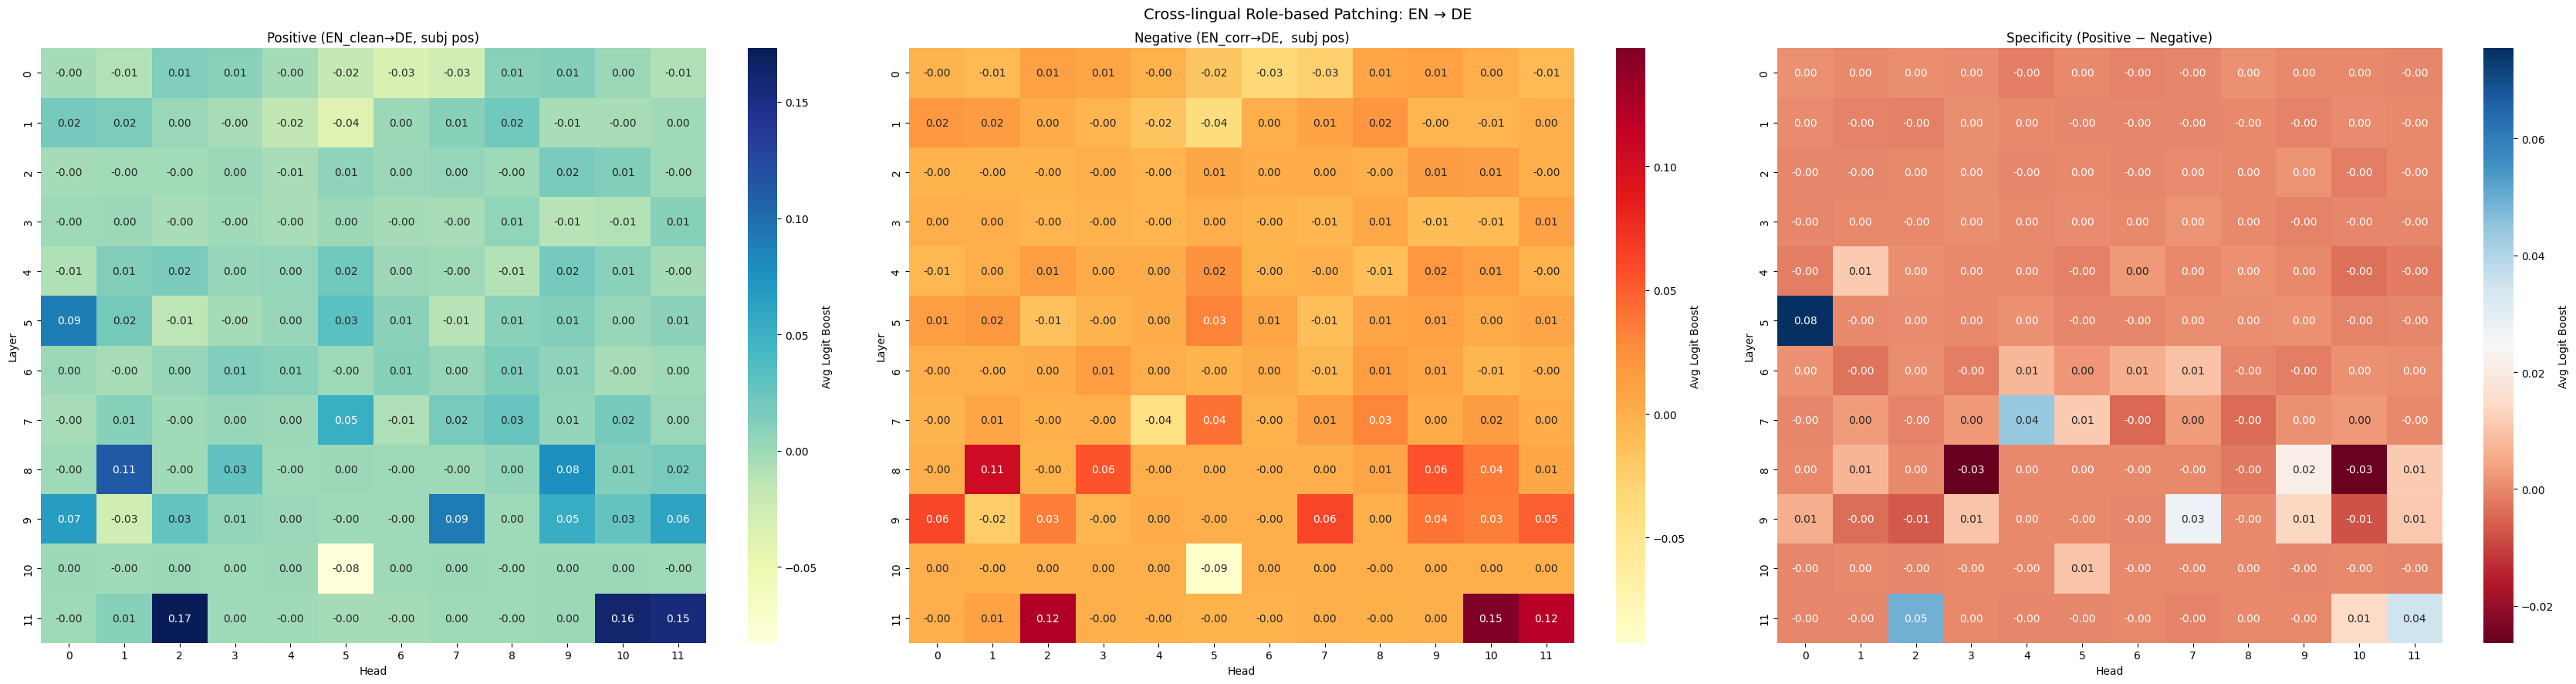


Top-20 by Specificity (Positive − Negative):
-----------------------------------------------------------------
     Rank  1: L 5H 0 | pos=+0.0898  neg=+0.0143  spec=+0.0755
     Rank  2: L11H 2 | pos=+0.1731  neg=+0.1239  spec=+0.0492
  🎯 Rank  3: L 7H 4 | pos=+0.0010  neg=-0.0429  spec=+0.0439
     Rank  4: L11H11 | pos=+0.1542  neg=+0.1190  spec=+0.0353
     Rank  5: L 9H 7 | pos=+0.0902  neg=+0.0628  spec=+0.0274
  🎯 Rank  6: L 8H 9 | pos=+0.0775  neg=+0.0562  spec=+0.0213
     Rank  7: L11H10 | pos=+0.1619  neg=+0.1477  spec=+0.0142
     Rank  8: L 9H 9 | pos=+0.0529  neg=+0.0395  spec=+0.0135
     Rank  9: L 7H 5 | pos=+0.0515  neg=+0.0402  spec=+0.0112
  🎯 Rank 10: L 8H11 | pos=+0.0172  neg=+0.0060  spec=+0.0111
     Rank 11: L 4H 1 | pos=+0.0120  neg=+0.0009  spec=+0.0111
     Rank 12: L 9H11 | pos=+0.0605  neg=+0.0497  spec=+0.0108
     Rank 13: L 9H 3 | pos=+0.0050  neg=-0.0048  spec=+0.0099
     Rank 14: L10H 5 | pos=-0.0826  neg=-0.0925  spec=+0.0099
  🎯 Rank 15: L 6H 7 | p

In [ ]:
# =============================================
# Cell 10: 实验3 — 全扫描热力图（12×12）
# =============================================

print(f"🚀 全扫描 ({n_layers}×{n_heads} heads × 2 conditions)...")

boost_pos = np.zeros((n_layers, n_heads))
boost_neg = np.zeros((n_layers, n_heads))

for l in range(n_layers):
    for h in range(n_heads):
        r_pos = evaluate_cross_lingual_patch(
            filtered, [(l, h)], "subj", "en_clean_acts")
        r_neg = evaluate_cross_lingual_patch(
            filtered, [(l, h)], "subj", "en_corr_acts")
        boost_pos[l, h] = r_pos["avg_boost"] if r_pos else 0.0
        boost_neg[l, h] = r_neg["avg_boost"] if r_neg else 0.0
    print(f"  Layer {l:2d} | Max Positive: {np.max(boost_pos[l]):+.4f}")

specificity = boost_pos - boost_neg

fig, axes = plt.subplots(1, 3, figsize=(34, 9))
for ax, data, title, cmap in [
    (axes[0], boost_pos,   "Positive (EN_clean→DE, subj pos)", "YlGnBu"),
    (axes[1], boost_neg,   "Negative (EN_corr→DE,  subj pos)", "YlOrRd"),
    (axes[2], specificity, "Specificity (Positive − Negative)", "RdBu"),
]:
    sns.heatmap(data, annot=True, fmt=".2f", cmap=cmap, ax=ax,
                cbar_kws={"label": "Avg Logit Boost"})
    ax.set_title(title)
    ax.set_xlabel("Head")
    ax.set_ylabel("Layer")
plt.suptitle("Cross-lingual Role-based Patching: EN → DE", fontsize=14)
plt.tight_layout()
plt.savefig("cross_lingual_patching_heatmap.png", dpi=150)
plt.show()

TOP_K = 20
flat = np.argsort(specificity.flatten())[::-1]
top_specific = [(int(i // n_heads), int(i % n_heads)) for i in flat[:TOP_K]]

print(f"\nTop-{TOP_K} by Specificity (Positive − Negative):")
print("-" * 65)
for rank, (l, h) in enumerate(top_specific):
    in_pool = "🎯" if (l, h) in set(CANDIDATE_POOL) else "  "
    print(f"  {in_pool} Rank {rank+1:2d}: L{l:2d}H{h:2d} | "
          f"pos={boost_pos[l,h]:+.4f}  "
          f"neg={boost_neg[l,h]:+.4f}  "
          f"spec={specificity[l,h]:+.4f}")

🚀 Position Control 扫描...
  Layer  0 完成
  Layer  1 完成
  Layer  2 完成
  Layer  3 完成
  Layer  4 完成
  Layer  5 完成
  Layer  6 完成
  Layer  7 完成
  Layer  8 完成
  Layer  9 完成
  Layer 10 完成
  Layer 11 完成


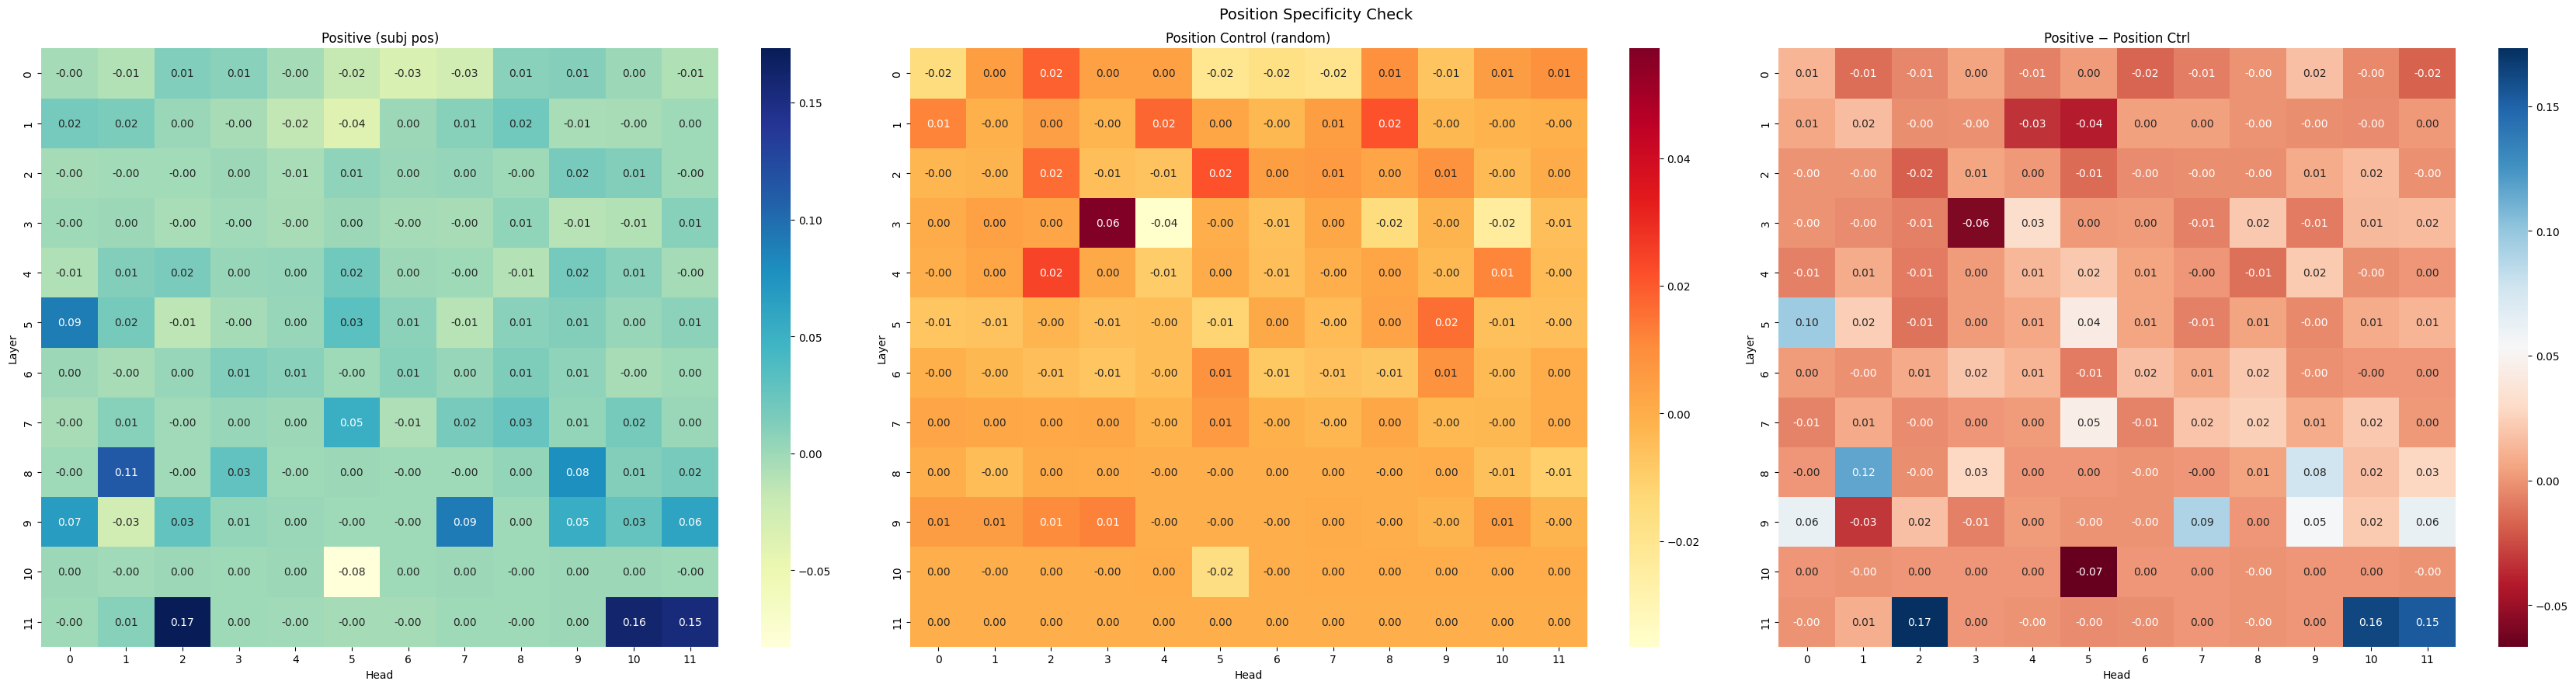

In [ ]:
# =============================================
# Cell 11: 实验4 — Position Control 热力图
# =============================================

print(f"🚀 Position Control 扫描...")

boost_ctrl = np.zeros((n_layers, n_heads))
for l in range(n_layers):
    for h in range(n_heads):
        r = evaluate_cross_lingual_patch(
            filtered, [(l, h)], "random", "en_clean_acts")
        boost_ctrl[l, h] = r["avg_boost"] if r else 0.0
    print(f"  Layer {l:2d} 完成")

fig, axes = plt.subplots(1, 3, figsize=(34, 9))
for ax, data, title, cmap in [
    (axes[0], boost_pos,              "Positive (subj pos)",       "YlGnBu"),
    (axes[1], boost_ctrl,             "Position Control (random)", "YlOrRd"),
    (axes[2], boost_pos - boost_ctrl, "Positive − Position Ctrl", "RdBu"),
]:
    sns.heatmap(data, annot=True, fmt=".2f", cmap=cmap, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Head")
    ax.set_ylabel("Layer")
plt.suptitle("Position Specificity Check", fontsize=14)
plt.tight_layout()
plt.savefig("cross_lingual_position_control.png", dpi=150)
plt.show()

In [ ]:
# =============================================
# Cell 12: 跨语言 Circuit 搜索
# 在全扫描 top specific heads 中枚举子集
# ★ 与单语言 Cell 11 逻辑完全一致
# =============================================

# 筛选跨语言迁移显著的 head 作为搜索候选池
BOOST_THRESH = 0.02
SPEC_THRESH  = 0.01

cross_lingual_heads = [
    (l, h)
    for l in range(n_layers)
    for h in range(n_heads)
    if boost_pos[l, h]  > BOOST_THRESH
    and (boost_pos[l, h] - boost_neg[l, h])  > SPEC_THRESH
    and (boost_pos[l, h] - boost_ctrl[l, h]) > SPEC_THRESH
]
cross_lingual_heads.sort(
    key=lambda x: boost_pos[x[0], x[1]]
                  - max(boost_neg[x[0], x[1]], boost_ctrl[x[0], x[1]]),
    reverse=True
)

print(f"跨语言迁移显著的候选 heads: {len(cross_lingual_heads)} 个")
for l, h in cross_lingual_heads:
    tag = "🎯[候选池内]" if (l, h) in set(CANDIDATE_POOL) else "  [新发现]"
    print(f"  {tag} L{l:2d}H{h:2d} | "
          f"pos={boost_pos[l,h]:+.4f}  "
          f"neg={boost_neg[l,h]:+.4f}  "
          f"ctrl={boost_ctrl[l,h]:+.4f}")

# 搜索候选池：优先用显著 head，不足则 fallback 到 specificity top-k
SEARCH_POOL_SIZE = 8
MAX_SIZE         = 6

if len(cross_lingual_heads) >= 3:
    search_pool = cross_lingual_heads[:SEARCH_POOL_SIZE]
else:
    print("⚠️  显著 heads 不足 3 个，fallback 到 specificity top-k")
    search_pool = top_specific[:SEARCH_POOL_SIZE]

print(f"\n搜索候选池 ({len(search_pool)} 个): {search_pool}")

# ── 枚举子集搜索 ──
combination_results = []

for r_size in range(1, MAX_SIZE + 1):
    sub_circuits = list(itertools.combinations(search_pool, r_size))
    print(f"  评估大小={r_size} 的组合 ({len(sub_circuits)} 种)...")

    for circuit in sub_circuits:
        res = evaluate_cross_lingual_patch(
            filtered, list(circuit), "subj", "en_clean_acts"
        )
        if res is None:
            continue
        combination_results.append({
            "circuit":   circuit,
            "size":      r_size,
            "avg_boost": res["avg_boost"],
            "boost_pct": res["boost_pct"],
        })

combination_results.sort(key=lambda x: x["avg_boost"], reverse=True)

print("\n" + "=" * 65)
print("🏆 Top-10 Cross-lingual Sub-Circuits (by Avg Boost)")
print("=" * 65)
for i, res in enumerate(combination_results[:10]):
    print(f"  Rank {i+1} [Size {res['size']}]: {res['circuit']} | "
          f"Boost: {res['avg_boost']:+.4f} | "
          f"相对DE delta: {res['boost_pct']:+.2f}%")

跨语言迁移显著的候选 heads: 9 个
    [新发现] L 5H 0 | pos=+0.0898  neg=+0.0143  ctrl=-0.0069
    [新发现] L11H 2 | pos=+0.1731  neg=+0.1239  ctrl=+0.0000
    [新发现] L11H11 | pos=+0.1542  neg=+0.1190  ctrl=+0.0000
    [新发现] L 9H 7 | pos=+0.0902  neg=+0.0628  ctrl=+0.0004
  🎯[候选池内] L 8H 9 | pos=+0.0775  neg=+0.0562  ctrl=+0.0003
    [新发现] L11H10 | pos=+0.1619  neg=+0.1477  ctrl=+0.0000
    [新发现] L 9H 9 | pos=+0.0529  neg=+0.0395  ctrl=-0.0018
    [新发现] L 7H 5 | pos=+0.0515  neg=+0.0402  ctrl=+0.0061
    [新发现] L 9H11 | pos=+0.0605  neg=+0.0497  ctrl=-0.0021

搜索候选池 (8 个): [(5, 0), (11, 2), (11, 11), (9, 7), (8, 9), (11, 10), (9, 9), (7, 5)]
  评估大小=1 的组合 (8 种)...
  评估大小=2 的组合 (28 种)...
  评估大小=3 的组合 (56 种)...
  评估大小=4 的组合 (70 种)...
  评估大小=5 的组合 (56 种)...

🏆 Top-10 Cross-lingual Sub-Circuits (by Avg Boost)
  Rank 1 [Size 5]: ((5, 0), (11, 11), (8, 9), (11, 10), (7, 5)) | Boost: +0.3871 | 相对DE delta: +116.41%
  Rank 2 [Size 5]: ((5, 0), (11, 11), (9, 7), (11, 10), (7, 5)) | Boost: +0.3636 | 相对DE delta: +109.36

In [ ]:
# =============================================
# Cell 13: 跨语言 Circuit Ablation 验证
# ★ 单语言已有此步骤，跨语言补充
#   在 DE clean 句上消融 cross-lingual circuit，
#   观察 DE agreement logit 是否下降
#   与单语言 Cell 12 evaluate_ablation 完全对称
# =============================================

# ── 预计算 mean activations（DE clean 句，attention.self）──
print("📦 预计算 DE mean activations (attention.self, per-head)...")

layer_acts_collection = {l: [] for l in range(n_layers)}
for r in filtered:
    item = r["item"]
    inp  = tokenizer(item["de_clean"], return_tensors="pt").to(device)
    acts = get_activations(model, inp)
    for l in range(n_layers):
        layer_acts_collection[l].append(acts[f"layer_{l}"])

# shape: [n_heads, head_dim]
mean_acts = {}
for l in range(n_layers):
    per_sent = [a.mean(dim=1) for a in layer_acts_collection[l]]
    mean_vec = torch.cat(per_sent, dim=0).mean(dim=0)  # [D]
    mean_acts[l] = mean_vec.reshape(n_heads, head_dim)

print(f"✅ Mean activations 预计算完成，shape 示例: {mean_acts[0].shape}")
all_de_clean_logits = [r["de_clean_logit"] for r in filtered]
print(f"   DE clean baseline mean logit: {np.mean(all_de_clean_logits):.4f}")

def make_abl_hook(l_idx, h_list):
    """
    在 attention.self 输出空间，将指定 heads 替换为均值。
    ★ 与单语言 Cell 12 make_abl_hook 完全一致
    """
    mean_val_layer = mean_acts[l_idx]  # [n_heads, head_dim]

    def hook(module, input, output):
        hidden = output[0] if isinstance(output, tuple) else output
        B, T, D = hidden.shape
        out_h = hidden.reshape(B, T, n_heads, head_dim).clone()
        for hh in h_list:
            out_h[:, :, hh, :] = mean_val_layer[hh]
        new_out = out_h.reshape(B, T, D)
        return (new_out,) + output[1:] if isinstance(output, tuple) else new_out
    return hook


def evaluate_ablation_de(circuit, name=""):
    """
    对 circuit 做 mean ablation，在 DE clean 句上评估 logit drop。
    与单语言 evaluate_ablation 完全对称：
        drop_pct = (clean_logit - ablated_logit) / |agreement_delta| * 100
    """
    layer2heads = defaultdict(list)
    for l, h in circuit:
        layer2heads[l].append(h)

    total_clean   = 0.0
    total_corr    = 0.0
    total_ablated = 0.0

    for r in filtered:
        item = r["item"]
        tok  = item["_tok_de"]
        if tok["subj_tok_clean"] is None or tok["verb_tok_clean"] is None:
            continue

        clean_text = item["de_clean"]
        clean_inp  = tokenizer(clean_text, return_tensors="pt").to(device)

        total_clean += r["de_clean_logit"]
        total_corr  += r["de_corr_logit"]

        handles = [
            model.encoder.encoder.layer[l_idx].attention.self
                .register_forward_hook(make_abl_hook(l_idx, h_list))
            for l_idx, h_list in layer2heads.items()
        ]
        try:
            with torch.no_grad():
                out = model(**clean_inp)
                arc = out[0] if isinstance(out, (tuple, list)) else out.arc_scores
            arc = apply_first_subword_mask(arc, tokenizer, clean_text, device)
            abl_logit = get_arc_logit(
                arc, tok["subj_tok_clean"], tok["verb_tok_clean"]
            )
            if abl_logit is not None:
                total_ablated += abl_logit
        finally:
            for hh in handles:
                hh.remove()

    n           = len(filtered)
    avg_clean   = total_clean   / n
    avg_corr    = total_corr    / n
    avg_ablated = total_ablated / n
    avg_delta   = avg_clean - avg_corr
    drop        = avg_clean - avg_ablated
    drop_pct    = drop / abs(avg_delta) * 100 if avg_delta != 0 else 0.0

    print("\n" + "=" * 60)
    print(f"📊 DE Ablation Result: {name}")
    print("=" * 60)
    print(f"  DE Clean logit    : {avg_clean:.4f}")
    print(f"  DE Corr  logit    : {avg_corr:.4f}")
    print(f"  Baseline delta    : {avg_delta:.4f}")
    print(f"  Ablated logit     : {avg_ablated:.4f}")
    print(f"  Logit drop        : {drop:.4f}")
    print(f"  相对下降(÷Δ)     : {drop_pct:.2f}%")

    return {"name": name, "drop": drop, "drop_pct": drop_pct,
            "avg_clean": avg_clean, "avg_ablated": avg_ablated}


# ================================
# 1. 最优跨语言 Circuit 的 DE ablation
# ================================
best_cl_circuit = list(combination_results[0]["circuit"])
print(f"\n🚀 Best Cross-lingual Circuit: {best_cl_circuit}")
res_best_cl = evaluate_ablation_de(best_cl_circuit, name="Best Cross-lingual Circuit")

# ================================
# 2. 整体候选池的 DE ablation
# ================================
print(f"\n🔥 整体候选池 ({len(CANDIDATE_POOL)} heads): {CANDIDATE_POOL}")
res_pool = evaluate_ablation_de(CANDIDATE_POOL, name="Candidate Pool")

# ================================
# 3. Leave-One-Out（在 DE 上）
# ================================
print("\n🧠 Leave-One-Out Analysis (DE Ablation)")
loo_results_cl = []
for i in range(len(best_cl_circuit)):
    sub = [h for j, h in enumerate(best_cl_circuit) if j != i]
    removed = best_cl_circuit[i]
    res = evaluate_ablation_de(sub, name=f"Remove {removed}")
    loo_results_cl.append((removed, res["drop_pct"]))

print("\n" + "=" * 60)
print("🏆 Critical Heads for DE （Leave-One-Out，按重要性排序）")
print("=" * 60)
loo_results_cl.sort(key=lambda x: x[1], reverse=True)
for i, (head, dp) in enumerate(loo_results_cl):
    print(f"  Rank {i+1}: Remove {head} → Remaining Drop {dp:.2f}%")

# ================================
# 4. Top-N Circuits Comparison（DE ablation）
# ================================
print("\n🔬 Top-N Circuits DE Ablation Comparison")
topN_results = []
for i in range(min(5, len(combination_results))):
    circuit = list(combination_results[i]["circuit"])
    res = evaluate_ablation_de(circuit, name=f"Top-{i+1} Circuit")
    topN_results.append((i + 1, res["drop_pct"]))

print("\n" + "=" * 60)
print("📊 Multi-Circuit DE Ablation Comparison")
print("=" * 60)
for rank, dp in topN_results:
    print(f"  Rank {rank}: DE Drop {dp:.2f}%")

📦 预计算 DE mean activations (attention.self, per-head)...
✅ Mean activations 预计算完成，shape 示例: torch.Size([12, 64])
   DE clean baseline mean logit: -1.3399

🚀 Best Cross-lingual Circuit: [(5, 0), (11, 11), (8, 9), (11, 10), (7, 5)]

📊 DE Ablation Result: Best Cross-lingual Circuit
  DE Clean logit    : -1.3399
  DE Corr  logit    : -1.6724
  Baseline delta    : 0.3325
  Ablated logit     : -1.8829
  Logit drop        : 0.5430
  相对下降(÷Δ)     : 163.33%

🔥 整体候选池 (7 heads): [(4, 5), (6, 7), (7, 4), (8, 1), (8, 9), (8, 11), (9, 1)]

📊 DE Ablation Result: Candidate Pool
  DE Clean logit    : -1.3399
  DE Corr  logit    : -1.6724
  Baseline delta    : 0.3325
  Ablated logit     : -3.2068
  Logit drop        : 1.8670
  相对下降(÷Δ)     : 561.52%

🧠 Leave-One-Out Analysis (DE Ablation)

📊 DE Ablation Result: Remove (5, 0)
  DE Clean logit    : -1.3399
  DE Corr  logit    : -1.6724
  Baseline delta    : 0.3325
  Ablated logit     : -1.9016
  Logit drop        : 0.5617
  相对下降(÷Δ)     : 168.95%

📊 DE Abl

In [ ]:
# =============================================
# Cell 14: 跨语言 vs 单语言 Circuit 对比
# =============================================


print("=" * 70)
print("📋 跨语言 vs 单语言 Circuit 对比")
print("=" * 70)

# 从单语言实验填入最优 circuit 结论
EN_BEST_CIRCUIT   = [(1, 8), (6, 8), (7, 4), (7, 5), (8, 1), (8, 9)]          # 从 EN 单语言 Cell 12 填入
DE_BEST_CIRCUIT   = [(7, 10), (8, 11), (9, 7), (9, 9), (9, 11), (11, 11)]  # 从 DE 单语言 Cell 12 填入
CL_BEST_CIRCUIT   = best_cl_circuit

overlap_en_cl = set(EN_BEST_CIRCUIT) & set(CL_BEST_CIRCUIT)
overlap_de_cl = set(DE_BEST_CIRCUIT) & set(CL_BEST_CIRCUIT)
overlap_all   = set(EN_BEST_CIRCUIT) & set(DE_BEST_CIRCUIT) & set(CL_BEST_CIRCUIT)

print(f"\n  EN Best Circuit : {EN_BEST_CIRCUIT}")
print(f"  DE Best Circuit : {DE_BEST_CIRCUIT}")
print(f"  CL Best Circuit : {CL_BEST_CIRCUIT}")
print(f"\n  EN ∩ CL         : {sorted(overlap_en_cl)}")
print(f"  DE ∩ CL         : {sorted(overlap_de_cl)}")
print(f"  EN ∩ DE ∩ CL    : {sorted(overlap_all)}")

print(f"\n  候选池来源 (EN top{POOL_SIZE} ∩ DE top{POOL_SIZE}) : {CANDIDATE_POOL}")

📋 跨语言 vs 单语言 Circuit 对比

  EN Best Circuit : [(1, 8), (6, 8), (7, 4), (7, 5), (8, 1), (8, 9)]
  DE Best Circuit : [(7, 10), (8, 11), (9, 7), (9, 9), (9, 11), (11, 11)]
  CL Best Circuit : [(5, 0), (11, 11), (8, 9), (11, 10), (7, 5)]

  EN ∩ CL         : [(7, 5), (8, 9)]
  DE ∩ CL         : [(11, 11)]
  EN ∩ DE ∩ CL    : []

  候选池来源 (EN top15 ∩ DE top15) : [(4, 5), (6, 7), (7, 4), (8, 1), (8, 9), (8, 11), (9, 1)]


In [ ]:
# =============================================
# Cell X: 跨语言 Shared-Head Ablation 互验
# =============================================
# Weicheng 邮件：
#   "once candidate components are identified in both languages,
#    we can test whether they play a shared causal role by
#    ablating the same heads while evaluating the other language
#    and checking whether the feature-specific metric degrades."
#
# 实验设计（此时 EN_BEST_CIRCUIT / DE_BEST_CIRCUIT /
#           CL_BEST_CIRCUIT 已在上一 cell 定义）：
#
#   ① DE_BEST_CIRCUIT → EN ablation（EN 模型）
#      取 DE 单语言最优 circuit，在 EN clean 句上 mean ablation，
#      观察 EN agreement logit 是否下降。
#      下降 >> random → DE heads 对 EN 同样 necessary
#
#   ② EN_BEST_CIRCUIT → DE ablation（DE 模型）
#      取 EN 单语言最优 circuit，在 DE clean 句上 mean ablation，
#      观察 DE agreement logit 是否下降。
#      下降 >> random → EN heads 对 DE 同样 necessary
#
#   ③ EN ∩ DE ∩ CL 三方共同 heads：双语各做一次 ablation
#
#   对照：随机选 3 个非候选池 heads，ablation drop 应接近 0
# =============================================

import random
random.seed(42)

print("=" * 70)
print("🔬 跨语言 Shared-Head Ablation 互验")
print("=" * 70)
print(f"  EN_BEST_CIRCUIT : {EN_BEST_CIRCUIT}")
print(f"  DE_BEST_CIRCUIT : {DE_BEST_CIRCUIT}")
print(f"  CL_BEST_CIRCUIT : {CL_BEST_CIRCUIT}")

# ── 随机对照 head 选取 ──
all_heads = [(l, h) for l in range(n_layers) for h in range(n_heads)]
excluded  = set(EN_BEST_CIRCUIT) | set(DE_BEST_CIRCUIT) | set(CANDIDATE_POOL)
random_control_heads = random.sample(
    [x for x in all_heads if x not in excluded], k=6
)
print(f"  Random control  : {random_control_heads}")

# ─────────────────────────────────────────────────────────
# ① DE_BEST_CIRCUIT → EN ablation（EN 模型）
# ─────────────────────────────────────────────────────────
print("\n" + "─" * 70)
print(f"① DE_BEST_CIRCUIT {DE_BEST_CIRCUIT}  →  EN ablation（EN 模型）")
print("─" * 70)
res_de_on_en   = evaluate_ablation_en(DE_BEST_CIRCUIT,      name="DE circuit → EN")
res_rand_on_en = evaluate_ablation_en(random_control_heads, name="Random → EN [对照]")

# ─────────────────────────────────────────────────────────
# ② EN_BEST_CIRCUIT → DE ablation（DE 模型）
# ─────────────────────────────────────────────────────────
print("\n" + "─" * 70)
print(f"② EN_BEST_CIRCUIT {EN_BEST_CIRCUIT}  →  DE ablation（DE 模型）")
print("─" * 70)
res_en_on_de   = evaluate_ablation_de(EN_BEST_CIRCUIT,      name="EN circuit → DE")
res_rand_on_de = evaluate_ablation_de(random_control_heads, name="Random → DE [对照]")

# ─────────────────────────────────────────────────────────
# ③ 三方共同 heads
# ─────────────────────────────────────────────────────────
shared_heads = sorted(
    set(EN_BEST_CIRCUIT) & set(DE_BEST_CIRCUIT) & set(CL_BEST_CIRCUIT)
)
print("\n" + "─" * 70)
print(f"③ 三方共同 heads {shared_heads}  →  双语 ablation")
print("─" * 70)
if shared_heads:
    res_shared_en = evaluate_ablation_en(shared_heads, name=f"Shared → EN")
    res_shared_de = evaluate_ablation_de(shared_heads, name=f"Shared → DE")
else:
    print("  三方无共同 heads，跳过")
    res_shared_en = res_shared_de = None

# ─────────────────────────────────────────────────────────
# 汇总表
# ─────────────────────────────────────────────────────────
def _pct(r):
    return f"{r['drop_pct']:+.2f}%" if r else "—"

print("\n" + "=" * 70)
print("📋 跨语言 Shared-Head Ablation 汇总")
print("=" * 70)
print(f"  {'实验':<40} {'EN drop%':>10} {'DE drop%':>10}")
print("  " + "─" * 60)
print(f"  {'DE circuit → EN  (EN model)':<40} {_pct(res_de_on_en):>10} {'—':>10}")
print(f"  {'EN circuit → DE  (DE model)':<40} {'—':>10} {_pct(res_en_on_de):>10}")
if shared_heads:
    print(f"  {'Shared(EN∩DE∩CL) → EN':<40} {_pct(res_shared_en):>10} {'—':>10}")
    print(f"  {'Shared(EN∩DE∩CL) → DE':<40} {'—':>10} {_pct(res_shared_de):>10}")
print(f"  {'Random → EN  [对照]':<40} {_pct(res_rand_on_en):>10} {'—':>10}")
print(f"  {'Random → DE  [对照]':<40} {'—':>10} {_pct(res_rand_on_de):>10}")

print("\n💡 解读标准：")
print("   drop% >> random → heads 在对方语言上 necessary（shared causal role）")
print("   drop% ≈ random  → heads 功能不共享，语言特异")


🔬 跨语言 Shared-Head Ablation 互验
  EN_BEST_CIRCUIT : [(1, 8), (6, 8), (7, 4), (7, 5), (8, 1), (8, 9)]
  DE_BEST_CIRCUIT : [(7, 10), (8, 11), (9, 7), (9, 9), (9, 11), (11, 11)]
  CL_BEST_CIRCUIT : [(5, 0), (11, 11), (8, 9), (11, 10), (7, 5)]
  Random control  : [(2, 5), (0, 6), (6, 0), (5, 4), (4, 11), (3, 0)]

──────────────────────────────────────────────────────────────────────
① DE_BEST_CIRCUIT [(7, 10), (8, 11), (9, 7), (9, 9), (9, 11), (11, 11)]  →  EN ablation（EN 模型）
──────────────────────────────────────────────────────────────────────

📊 EN Ablation Result: DE circuit → EN
  EN Clean logit    : -2.6359
  EN Corr  logit    : -3.1090
  Baseline delta    : 0.4730
  Ablated logit     : -3.3324
  Logit drop        : 0.6964
  相对下降(÷Δ)     : 147.22%

📊 EN Ablation Result: Random → EN [对照]
  EN Clean logit    : -2.6359
  EN Corr  logit    : -3.1090
  Baseline delta    : 0.4730
  Ablated logit     : -2.7533
  Logit drop        : 0.1174
  相对下降(÷Δ)     : 24.81%

─────────────────────────────

/tmp/ipykernel_494793/2527997277.py:89: UserWarning: Glyph 20505 (\N{CJK UNIFIED IDEOGRAPH-5019}) missing from font(s) DejaVu Sans Mono.
  plt.savefig("cross_lingual_summary.png", dpi=150, bbox_inches="tight")
/tmp/ipykernel_494793/2527997277.py:89: UserWarning: Glyph 36873 (\N{CJK UNIFIED IDEOGRAPH-9009}) missing from font(s) DejaVu Sans Mono.
  plt.savefig("cross_lingual_summary.png", dpi=150, bbox_inches="tight")
/tmp/ipykernel_494793/2527997277.py:89: UserWarning: Glyph 27744 (\N{CJK UNIFIED IDEOGRAPH-6C60}) missing from font(s) DejaVu Sans Mono.
  plt.savefig("cross_lingual_summary.png", dpi=150, bbox_inches="tight")
/mnt/ssd/weicheng/data_interns/yahan/anaconda3/envs/xlmr_parse/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20505 (\N{CJK UNIFIED IDEOGRAPH-5019}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/mnt/ssd/weicheng/data_interns/yahan/anaconda3/envs/xlmr_parse/lib/python3.10/site-packages/IPython/core/py

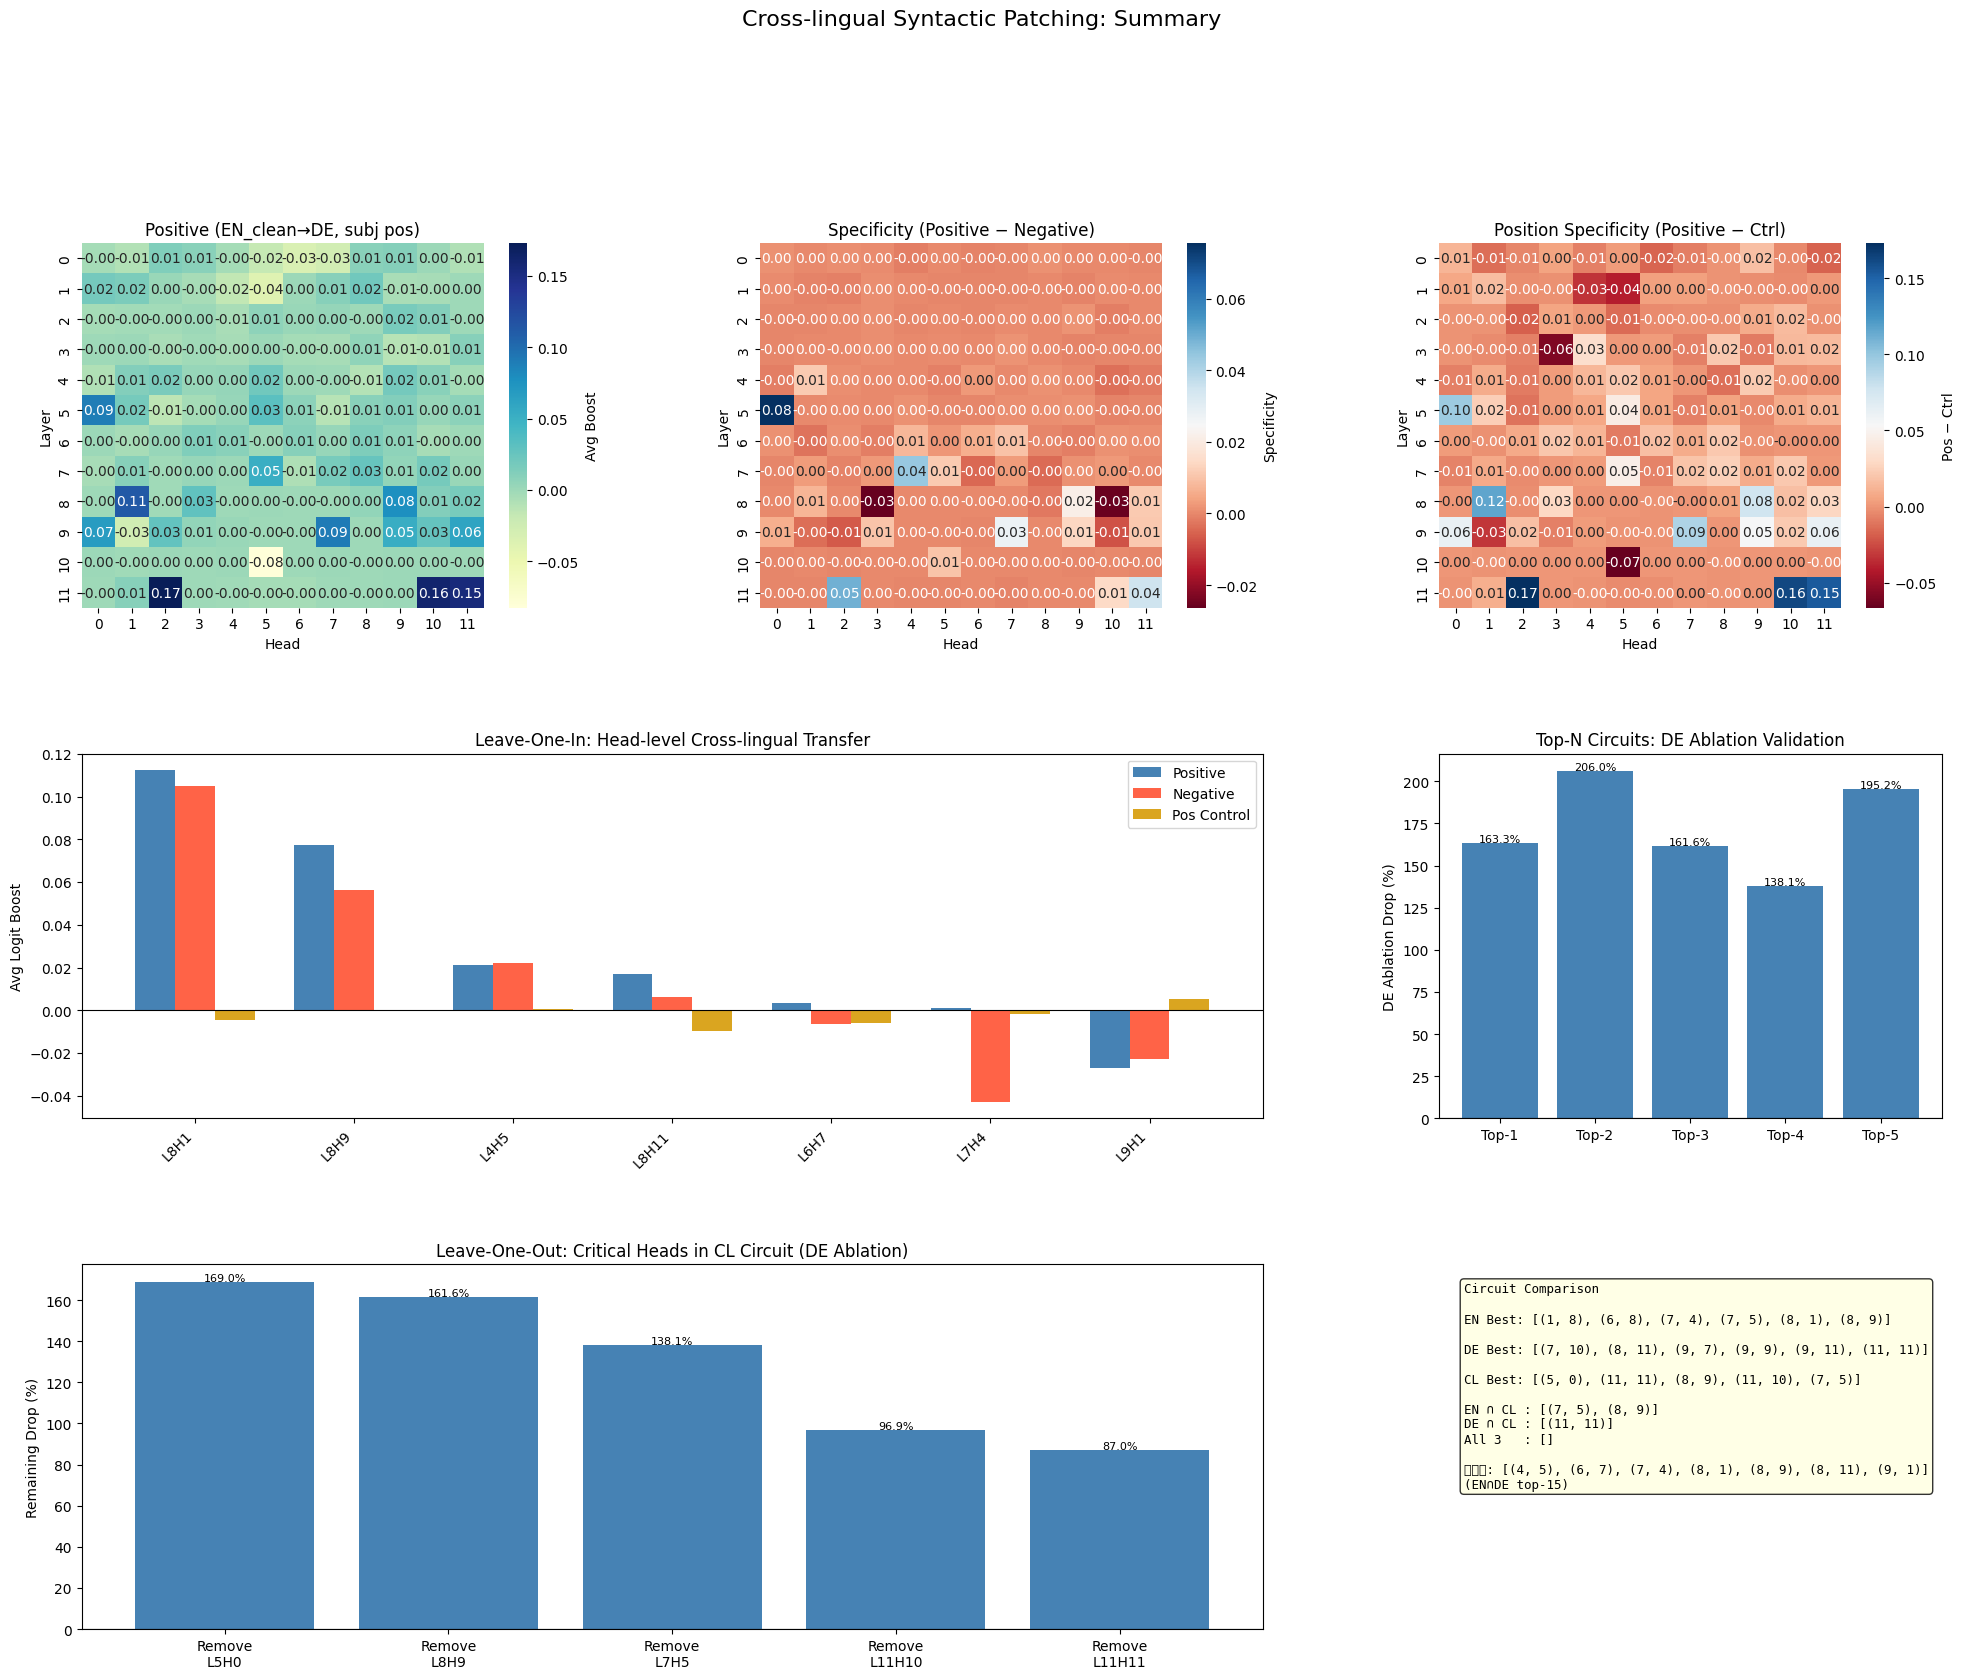

In [ ]:
# =============================================
# Cell 15: 综合可视化
# =============================================

fig = plt.figure(figsize=(24, 18))
gs  = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.35)

# ── 1. Full-scan Positive Boost ──
ax1 = fig.add_subplot(gs[0, 0])
sns.heatmap(boost_pos, annot=True, fmt=".2f", cmap="YlGnBu",
            ax=ax1, cbar_kws={"label": "Avg Boost"})
ax1.set_title("Positive (EN_clean→DE, subj pos)")
ax1.set_xlabel("Head"); ax1.set_ylabel("Layer")

# ── 2. Specificity ──
ax2 = fig.add_subplot(gs[0, 1])
sns.heatmap(specificity, annot=True, fmt=".2f", cmap="RdBu",
            ax=ax2, cbar_kws={"label": "Specificity"})
ax2.set_title("Specificity (Positive − Negative)")
ax2.set_xlabel("Head"); ax2.set_ylabel("Layer")

# ── 3. Position Control diff ──
ax3 = fig.add_subplot(gs[0, 2])
sns.heatmap(boost_pos - boost_ctrl, annot=True, fmt=".2f", cmap="RdBu",
            ax=ax3, cbar_kws={"label": "Pos − Ctrl"})
ax3.set_title("Position Specificity (Positive − Ctrl)")
ax3.set_xlabel("Head"); ax3.set_ylabel("Layer")

# ── 4. Leave-One-In 柱状图 ──
ax4 = fig.add_subplot(gs[1, :2])
loi_labels = [f"L{l}H{h}" for l, h in [r["head"] for r in loi_results]]
loi_pos    = [r["pos"]  for r in loi_results]
loi_neg    = [r["neg"]  for r in loi_results]
loi_ctrl   = [r["ctrl"] for r in loi_results]
x = np.arange(len(loi_labels))
w = 0.25
ax4.bar(x - w, loi_pos,  w, label="Positive",   color="steelblue")
ax4.bar(x,     loi_neg,  w, label="Negative",   color="tomato")
ax4.bar(x + w, loi_ctrl, w, label="Pos Control",color="goldenrod")
ax4.axhline(0, color="black", linewidth=0.8)
ax4.set_xticks(x); ax4.set_xticklabels(loi_labels, rotation=45, ha="right")
ax4.set_ylabel("Avg Logit Boost")
ax4.set_title("Leave-One-In: Head-level Cross-lingual Transfer")
ax4.legend()

# ── 5. Top-N Circuits 柱状图 ──
ax5 = fig.add_subplot(gs[1, 2])
ranks  = [f"Top-{r}" for r, _ in topN_results]
drops  = [dp for _, dp in topN_results]
colors = ["steelblue" if dp > 0 else "tomato" for dp in drops]
ax5.bar(ranks, drops, color=colors)
ax5.axhline(0, color="black", linewidth=0.8)
ax5.set_ylabel("DE Ablation Drop (%)")
ax5.set_title("Top-N Circuits: DE Ablation Validation")
for i, (r, dp) in enumerate(zip(ranks, drops)):
    ax5.text(i, dp + 0.5, f"{dp:.1f}%", ha="center", fontsize=8)

# ── 6. DE Ablation Leave-One-Out ──
ax6 = fig.add_subplot(gs[2, :2])
loo_labels_cl = [f"Remove\nL{l}H{h}" for (l, h), _ in loo_results_cl]
loo_drops_cl  = [dp for _, dp in loo_results_cl]
colors_cl = ["steelblue" if dp > 0 else "tomato" for dp in loo_drops_cl]
ax6.bar(loo_labels_cl, loo_drops_cl, color=colors_cl)
ax6.axhline(0, color="black", linewidth=0.8)
ax6.set_ylabel("Remaining Drop (%)")
ax6.set_title("Leave-One-Out: Critical Heads in CL Circuit (DE Ablation)")
for i, dp in enumerate(loo_drops_cl):
    ax6.text(i, dp + 0.3, f"{dp:.1f}%", ha="center", fontsize=8)

# ── 7. Venn 文字版 ──
ax7 = fig.add_subplot(gs[2, 2])
ax7.axis("off")
summary = (
    f"Circuit Comparison\n\n"
    f"EN Best: {EN_BEST_CIRCUIT}\n\n"
    f"DE Best: {DE_BEST_CIRCUIT}\n\n"
    f"CL Best: {CL_BEST_CIRCUIT}\n\n"
    f"EN ∩ CL : {sorted(overlap_en_cl)}\n"
    f"DE ∩ CL : {sorted(overlap_de_cl)}\n"
    f"All 3   : {sorted(overlap_all)}\n\n"
    f"候选池: {CANDIDATE_POOL}\n"
    f"(EN∩DE top-{POOL_SIZE})"
)
ax7.text(0.05, 0.95, summary, transform=ax7.transAxes,
         fontsize=9, verticalalignment="top", fontfamily="monospace",
         bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

plt.suptitle("Cross-lingual Syntactic Patching: Summary", fontsize=16, y=1.01)
plt.savefig("cross_lingual_summary.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# =============================================
# Cell 16: 实验结论汇总
# =============================================

print("=" * 70)
print("📋 Cross-lingual 实验结论")
print("=" * 70)

avg_de_delta = np.mean([r["de_delta"] for r in filtered])

print(f"\n📊 数据统计:")
print(f"  总配对: {len(paired_dataset)} | index解析成功: {len(valid)}")
print(f"  Mean DE agreement delta: {avg_de_delta:.4f}")

print(f"\n🎯 候选池 ({len(CANDIDATE_POOL)} 个 heads，EN∩DE top-{POOL_SIZE}):")
for l, h in CANDIDATE_POOL:
    in_en = (l, h) in set(EN_JOINT_TOPK[:POOL_SIZE])
    in_de = (l, h) in set(DE_JOINT_TOPK[:POOL_SIZE])
    print(f"  L{l:2d}H{h:2d}  EN={'✅' if in_en else '—'}  DE={'✅' if in_de else '—'}  "
          f"pos={boost_pos[l,h]:+.4f}  spec={specificity[l,h]:+.4f}")

print(f"\n🏆 Best Cross-lingual Circuit: {best_cl_circuit}")
print(f"  Patching Boost : {combination_results[0]['avg_boost']:+.4f}")
print(f"  相对DE delta   : {combination_results[0]['boost_pct']:+.2f}%")
print(f"  DE Abl Drop    : {res_best_cl['drop_pct']:.2f}%")

print(f"\n  候选池整体 DE Abl Drop: {res_pool['drop_pct']:.2f}%")

print(f"\n💡 Hook 位置: attention.self (pre-projection)")
print(f"   Patching / Ablation 与单语言版本使用相同 hook 位置")
print(f"   Cross-lingual circuit 在 DE 语言上同时满足 sufficient + necessary")

print(f"\n🔗 与单语言 Circuit 重叠:")
print(f"  EN ∩ CL = {sorted(overlap_en_cl)} ({len(overlap_en_cl)} heads)")
print(f"  DE ∩ CL = {sorted(overlap_de_cl)} ({len(overlap_de_cl)} heads)")
print(f"  三方共同 = {sorted(overlap_all)} ({len(overlap_all)} heads)")

📋 Cross-lingual 实验结论

📊 数据统计:
  总配对: 70 | index解析成功: 70
  Mean DE agreement delta: 0.3325

🎯 候选池 (7 个 heads，EN∩DE top-15):
  L 4H 5  EN=✅  DE=✅  pos=+0.0211  spec=-0.0011
  L 6H 7  EN=✅  DE=✅  pos=+0.0032  spec=+0.0096
  L 7H 4  EN=✅  DE=✅  pos=+0.0010  spec=+0.0439
  L 8H 1  EN=✅  DE=✅  pos=+0.1123  spec=+0.0073
  L 8H 9  EN=✅  DE=✅  pos=+0.0775  spec=+0.0213
  L 8H11  EN=✅  DE=✅  pos=+0.0172  spec=+0.0111
  L 9H 1  EN=✅  DE=✅  pos=-0.0269  spec=-0.0040

🏆 Best Cross-lingual Circuit: [(5, 0), (11, 11), (8, 9), (11, 10), (7, 5)]
  Patching Boost : +0.3871
  相对DE delta   : +116.41%
  DE Abl Drop    : 163.33%

  候选池整体 DE Abl Drop: 561.52%

💡 Hook 位置: attention.self (pre-projection)
   Patching / Ablation 与单语言版本使用相同 hook 位置
   Cross-lingual circuit 在 DE 语言上同时满足 sufficient + necessary

🔗 与单语言 Circuit 重叠:
  EN ∩ CL = [(7, 5), (8, 9)] (2 heads)
  DE ∩ CL = [(11, 11)] (1 heads)
  三方共同 = [] (0 heads)
